# Customer Churn Prediction and Analytics Using Machine Learning

**Internship:** AICTE + IBM SkillsBuild Data Analytics with AI  
**Dataset:** IBM Telco Customer Churn (Kaggle)  
**Tools:** Python · pandas · numpy · matplotlib · seaborn · scikit-learn  
**random_state:** 42 (used consistently for reproducibility)

---

## 1. Business Problem

Customer churn — the decision by a customer to stop using a service — is one of the most costly challenges in the telecommunications industry. Acquiring a new customer typically costs several times more than retaining an existing one. A predictive model that identifies customers likely to churn allows a business to intervene proactively with targeted retention offers, thereby reducing revenue loss.

**Objective:** Build and evaluate supervised machine learning classification models that predict whether a telecom customer will churn, and derive actionable business insights from the data and model outputs.

**Target variable:** `Churn` (Yes / No → 1 / 0)  
**Task type:** Binary classification  
**Success criteria:** Models evaluated on Accuracy, Precision, Recall, F1-score, and ROC-AUC. The best model is selected objectively from actual evaluation results — no assumptions are made in advance.

---
## 2. Dataset Description

The dataset is the **IBM Telco Customer Churn** dataset, publicly available on Kaggle. It contains information about 7,043 customers of a fictional California telecom provider, including demographics, account information, and the services each customer subscribes to.

| Column Group | Columns |
|---|---|
| Customer identity | `customerID` |
| Demographics | `gender`, `SeniorCitizen`, `Partner`, `Dependents` |
| Account | `tenure`, `Contract`, `PaperlessBilling`, `PaymentMethod`, `MonthlyCharges`, `TotalCharges` |
| Phone services | `PhoneService`, `MultipleLines` |
| Internet services | `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies` |
| Target | `Churn` |

**Known data quality note:** `TotalCharges` is stored as a string column in the CSV. Eleven rows contain whitespace values that must be handled explicitly during cleaning.

---
## 3. Library Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

from matplotlib.patches import Patch

# Plotting defaults
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13, 'axes.labelsize': 11})

RANDOM_STATE = 42
print('All libraries imported successfully.')

All libraries imported successfully.


---
## 4. Data Loading

The raw CSV is loaded into `df_raw`. **This variable is never modified** — all cleaning is performed on a copy.

In [2]:
DATA_PATH = '../data/WA_Fn-UseC_-Telco-Customer-Churn.csv'

# Load without modifying the source file
df_raw = pd.read_csv(DATA_PATH)

print(f'Shape: {df_raw.shape}')
df_raw.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print('Column names and dtypes:')
print(df_raw.dtypes.to_string())

Column names and dtypes:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object


---
## 5. Data Quality Inspection

Before any cleaning, we audit the raw data for:
- Missing / null values (including hidden whitespace blanks in `TotalCharges`)
- Duplicate rows
- Unexpected data types
- Class balance of the target variable

In [4]:
print('=== Explicit null counts ===')
print(df_raw.isnull().sum().to_string())

=== Explicit null counts ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0


In [5]:
# TotalCharges is object dtype — detect hidden whitespace values
blank_mask = df_raw['TotalCharges'].str.strip() == ''
print(f'TotalCharges rows with whitespace/blank: {blank_mask.sum()}')
print(df_raw.loc[blank_mask, ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']])

TotalCharges rows with whitespace/blank: 11
      customerID  tenure  MonthlyCharges TotalCharges Churn
488   4472-LVYGI       0           52.55                 No
753   3115-CZMZD       0           20.25                 No
936   5709-LVOEQ       0           80.85                 No
1082  4367-NUYAO       0           25.75                 No
1340  1371-DWPAZ       0           56.05                 No
3331  7644-OMVMY       0           19.85                 No
3826  3213-VVOLG       0           25.35                 No
4380  2520-SGTTA       0           20.00                 No
5218  2923-ARZLG       0           19.70                 No
6670  4075-WKNIU       0           73.35                 No
6754  2775-SEFEE       0           61.90                 No


In [6]:
print(f'Duplicate rows: {df_raw.duplicated().sum()}')

Duplicate rows: 0


In [7]:
print('=== Descriptive statistics (numeric columns) ===')
df_raw.describe()

=== Descriptive statistics (numeric columns) ===


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Churn class distribution:
       Count  Percentage (%)
Churn                       
No      5174           73.46
Yes     1869           26.54


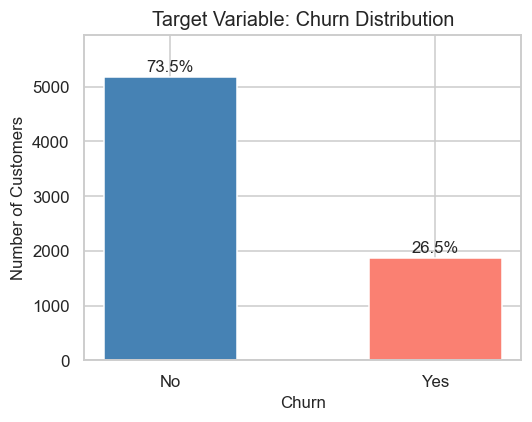

In [8]:
# Target class distribution
churn_counts = df_raw['Churn'].value_counts()
churn_pct = df_raw['Churn'].value_counts(normalize=True) * 100

print('Churn class distribution:')
dist_df = pd.DataFrame({'Count': churn_counts, 'Percentage (%)': churn_pct.round(2)})
print(dist_df)

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(churn_counts.index, churn_counts.values,
              color=['steelblue', 'salmon'], edgecolor='white', width=0.5)
for bar, pct in zip(bars, churn_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=11)
ax.set_title('Target Variable: Churn Distribution')
ax.set_xlabel('Churn')
ax.set_ylabel('Number of Customers')
ax.set_ylim(0, max(churn_counts.values) * 1.15)
plt.tight_layout()
plt.show()

**Quality summary:**
- No explicit null values in any column.
- `TotalCharges` contains 11 rows with whitespace values — these will be converted to `NaN` during numeric conversion and then imputed using the training-set median inside the preprocessing pipeline.
- No duplicate rows.
- The target class is imbalanced: approximately 73.5% No-churn vs. 26.5% Churn. This imbalance must be accounted for in model evaluation — **accuracy alone is an insufficient metric** (a naive classifier that always predicts "No" would score ~73.5% accuracy while identifying zero churners).

---
## 6. Data Cleaning and Preprocessing

We work on a **copy** of the raw DataFrame, leaving `df_raw` untouched.

Steps:
1. Drop `customerID` (non-predictive identifier)
2. Convert `TotalCharges` to numeric — the 11 whitespace values become `NaN`
3. Encode the binary target `Churn` as 0/1
4. Consolidate redundant category levels: `"No internet service"` and `"No phone service"` are semantically equivalent to `"No"` for the add-on service columns — collapsing them reduces cardinality without information loss.

> **Data leakage prevention:** Imputation, scaling, and encoding of feature columns are performed inside a scikit-learn `Pipeline` + `ColumnTransformer` that is **fitted only on the training data** and then applied to the test set. No test-set information influences any fitted transformer.

In [9]:
df = df_raw.copy()

# 1. Drop customerID
df.drop(columns=['customerID'], inplace=True)

# 2. Convert TotalCharges to numeric — blanks become NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f'TotalCharges NaN after numeric conversion: {df["TotalCharges"].isna().sum()}')

# 3. Encode target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 4. Consolidate redundant category levels in add-on service columns
service_cols = [
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]
for col in service_cols:
    df[col] = df[col].replace({'No internet service': 'No', 'No phone service': 'No'})

print(f'DataFrame shape after cleaning: {df.shape}')
print(f'Remaining NaN values per column (TotalCharges only expected):')
print(df.isnull().sum()[df.isnull().sum() > 0])
df.head(3)

TotalCharges NaN after numeric conversion: 11


DataFrame shape after cleaning: (7043, 20)
Remaining NaN values per column (TotalCharges only expected):
TotalCharges    11
dtype: int64


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


---
## 7. Feature Engineering

We derive a small number of additional features that may capture useful patterns not directly available in the raw columns:

| Feature | Formula | Rationale |
|---|---|---|
| `NumAddOnServices` | Count of `"Yes"` across the 7 service add-on columns | Summarises service depth as a single numeric value |
| `TenureGroup` | Binned tenure: 0–12, 13–24, 25–48, 49–72 months | Used for EDA only — captures lifecycle stage visually |

In [10]:
# NumAddOnServices: count of 'Yes' across service add-on columns
df['NumAddOnServices'] = df[service_cols].apply(lambda row: (row == 'Yes').sum(), axis=1)

# TenureGroup: for EDA visualisation only
tenure_bins = [0, 12, 24, 48, 72]
tenure_labels = ['0-12 mo', '13-24 mo', '25-48 mo', '49-72 mo']
df['TenureGroup'] = pd.cut(df['tenure'], bins=tenure_bins, labels=tenure_labels,
                            include_lowest=True)

print('New features added.')
print(df[['tenure', 'TenureGroup', 'NumAddOnServices']].head(5))

New features added.
   tenure TenureGroup  NumAddOnServices
0       1     0-12 mo                 1
1      34    25-48 mo                 2
2       2     0-12 mo                 2
3      45    25-48 mo                 3
4       2     0-12 mo                 0


---
## 8. Exploratory Data Analysis

EDA is performed on the full cleaned dataset **before** the train/test split, so we can understand the overall population. All observations describe patterns in the data; causal interpretations are reserved for the business insights section after modelling.

`TenureGroup` is used here for visualisation and will be excluded from the model feature set (it is redundant with the numeric `tenure` column).

### 8.1 Distributions of Numeric Features

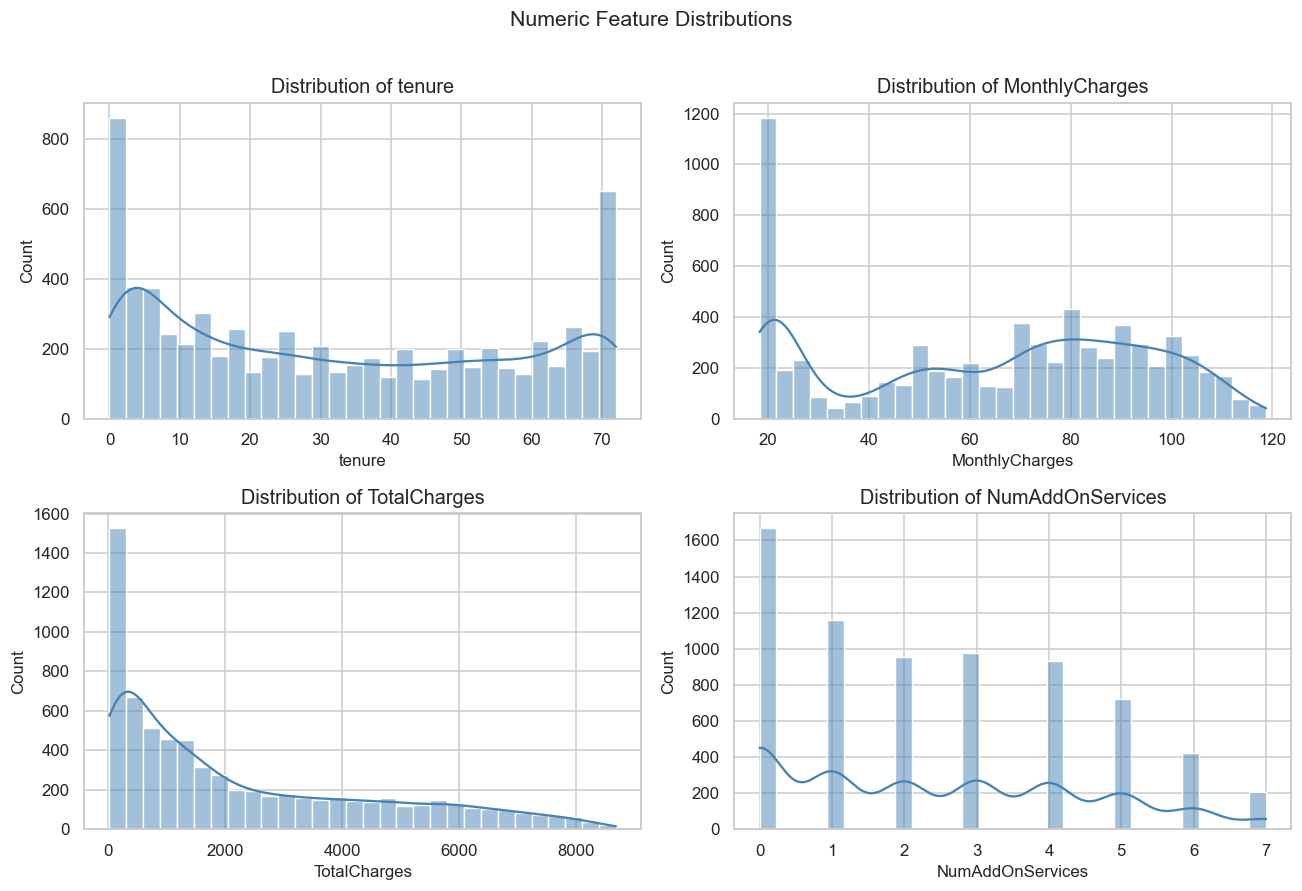

In [11]:
num_cols_eda = ['tenure', 'MonthlyCharges', 'TotalCharges', 'NumAddOnServices']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), num_cols_eda):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color='steelblue', bins=30)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
plt.suptitle('Numeric Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 8.2 Numeric Features vs. Churn

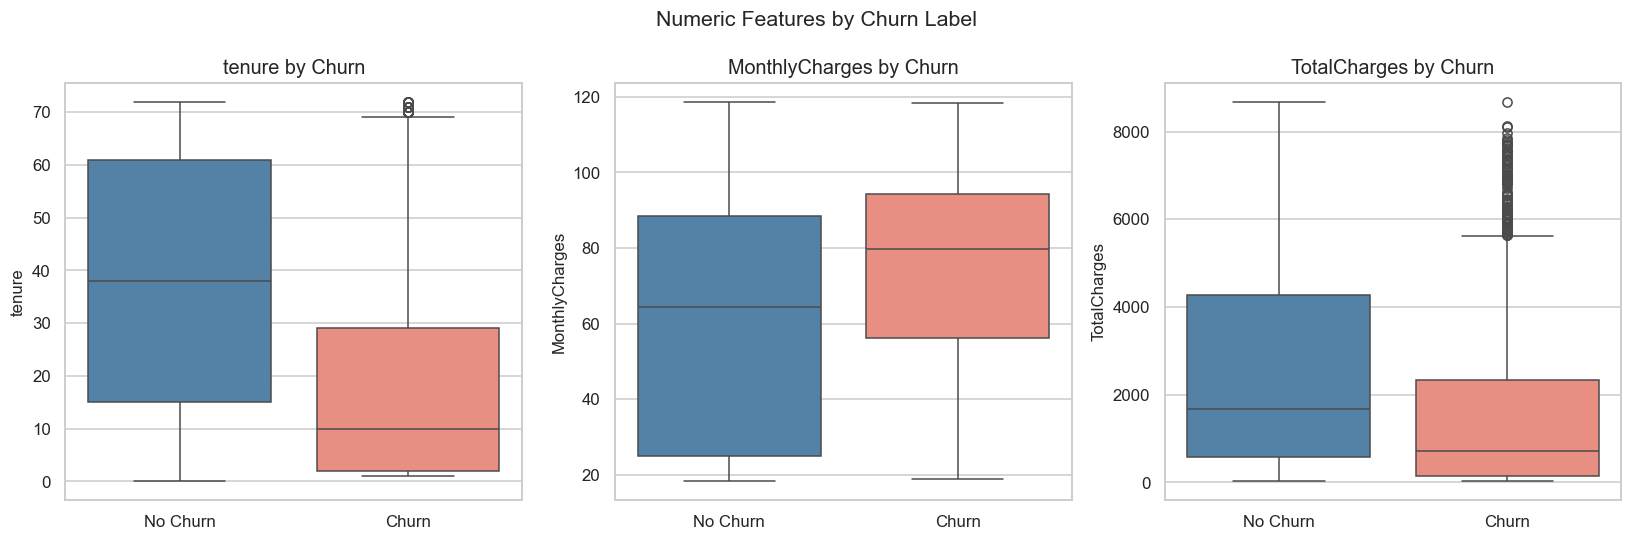

In [12]:
# Use a string label column for clean seaborn categorical axis
df['Churn_label'] = df['Churn'].map({0: 'No Churn', 1: 'Churn'})

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
palette_churn = {'No Churn': 'steelblue', 'Churn': 'salmon'}
for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.boxplot(data=df, x='Churn_label', y=col, ax=ax,
                palette=palette_churn, order=['No Churn', 'Churn'])
    ax.set_title(f'{col} by Churn')
    ax.set_xlabel('')
plt.suptitle('Numeric Features by Churn Label', fontsize=14)
plt.tight_layout()
plt.show()

df.drop(columns=['Churn_label'], inplace=True)

### 8.3 Churn Rate by Categorical Features

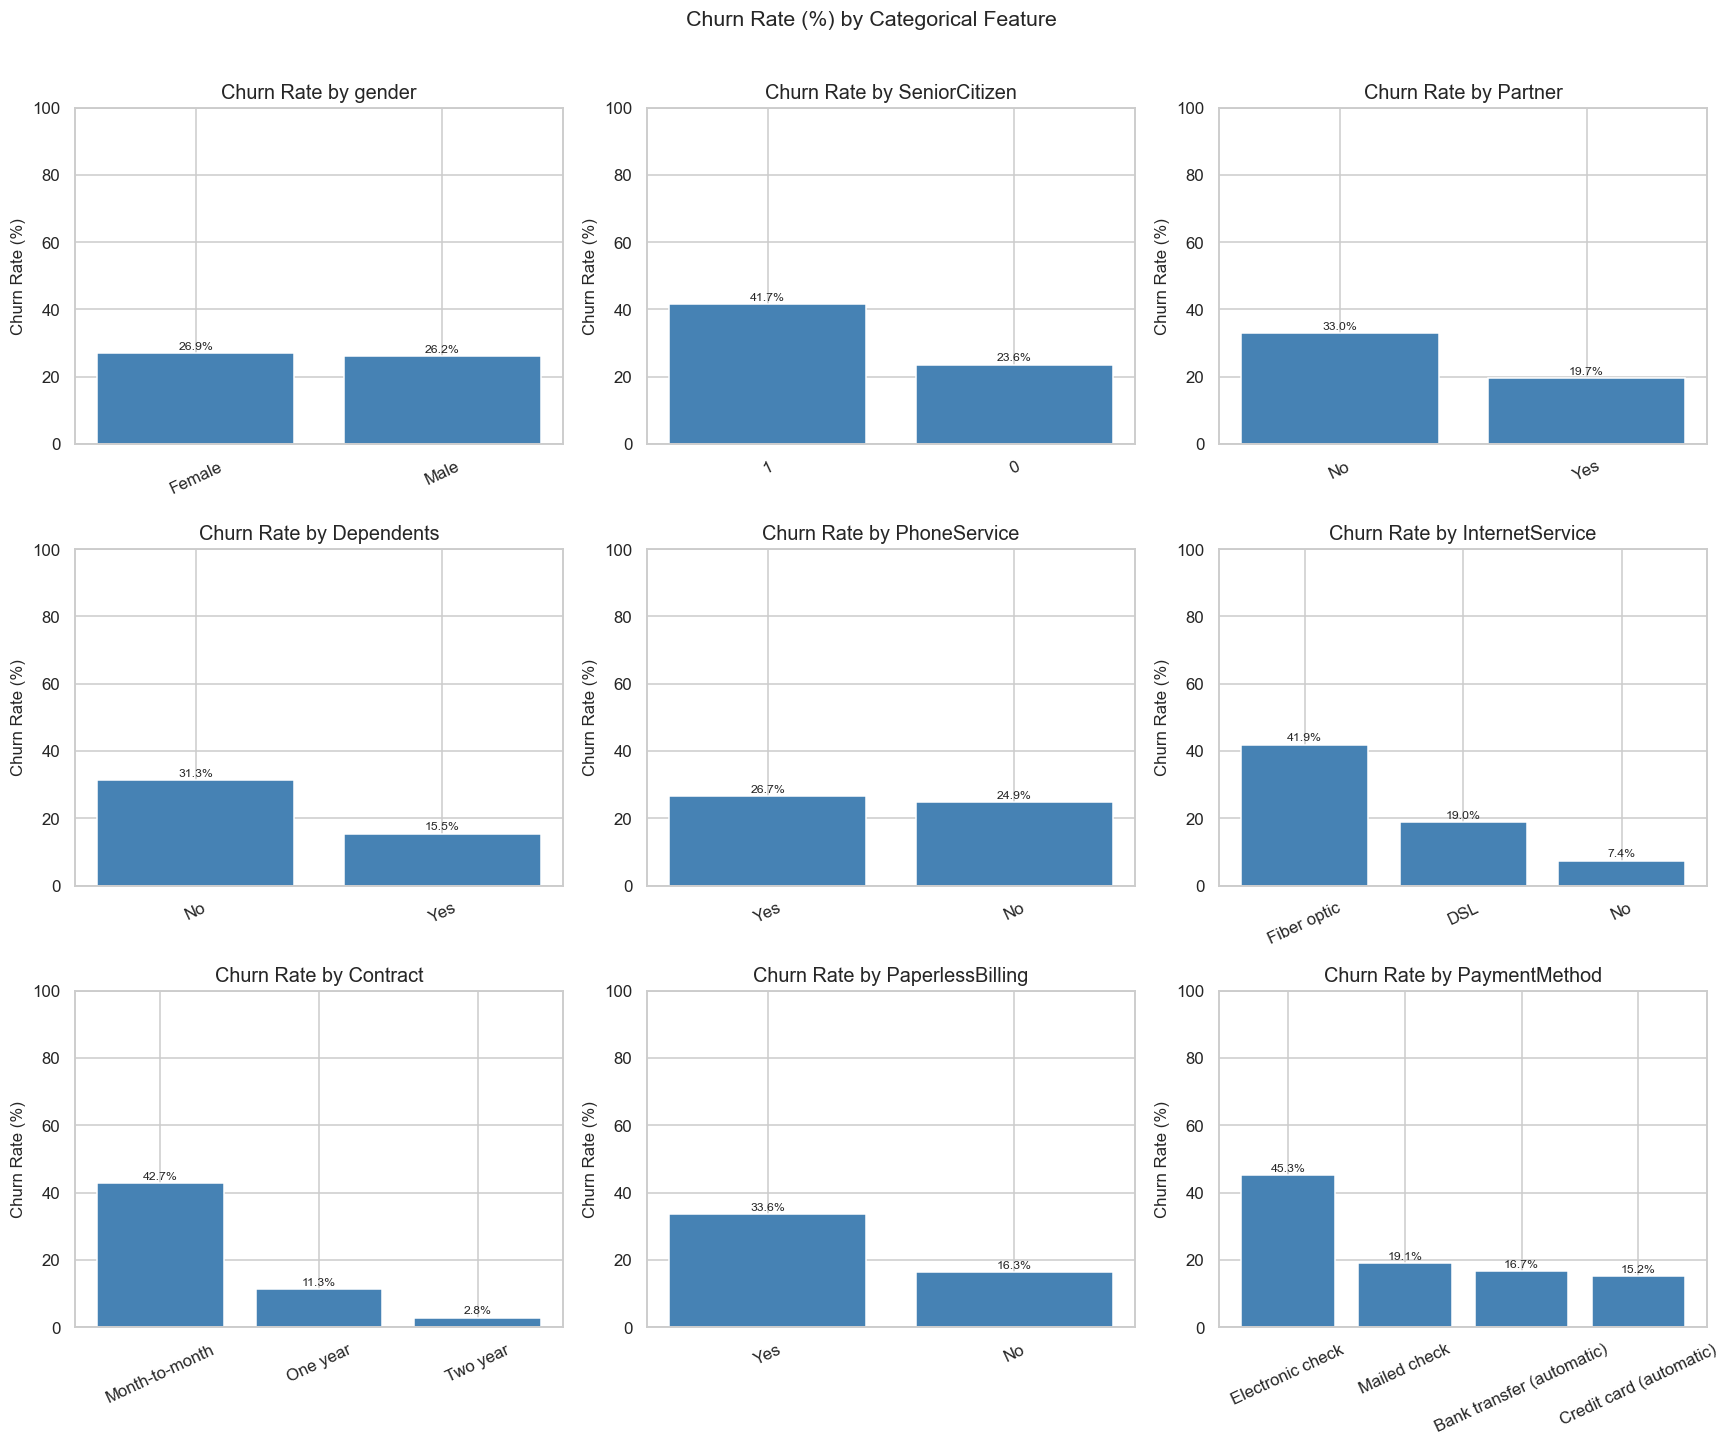

In [13]:
cat_churn_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'InternetService', 'Contract',
    'PaperlessBilling', 'PaymentMethod'
]

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
for ax, col in zip(axes.flatten(), cat_churn_cols):
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    bars = ax.bar(churn_rate.index.astype(str), churn_rate.values * 100,
                  color='steelblue', edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)
    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Churn Rate (%)')
    ax.tick_params(axis='x', rotation=25)
    ax.set_ylim(0, 100)
plt.suptitle('Churn Rate (%) by Categorical Feature', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 8.4 Churn Rate by Service Add-Ons and Tenure Group

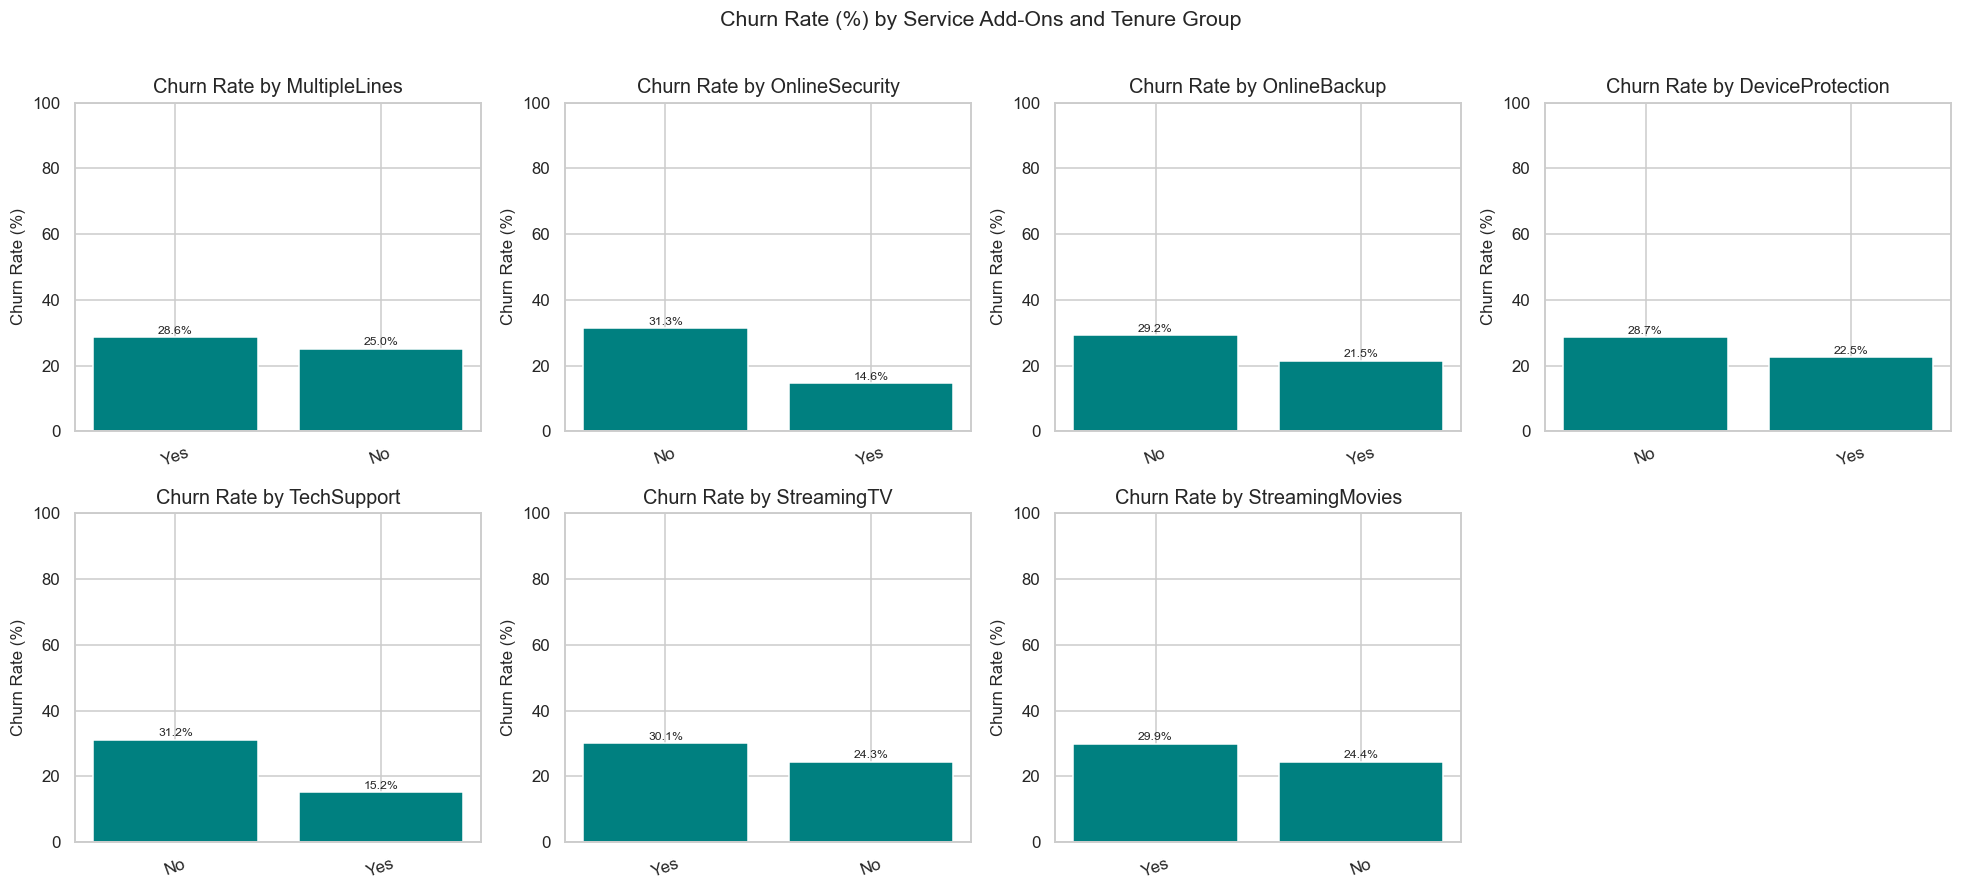

In [14]:
addon_eda_cols = service_cols + ['TenureGroup']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), addon_eda_cols):
    churn_rate = df.groupby(col, observed=True)['Churn'].mean().sort_values(ascending=False)
    bars = ax.bar(churn_rate.index.astype(str), churn_rate.values * 100,
                  color='teal', edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)
    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Churn Rate (%)')
    ax.tick_params(axis='x', rotation=20)
    ax.set_ylim(0, 100)
# Hide unused subplot
axes.flatten()[-1].set_visible(False)
plt.suptitle('Churn Rate (%) by Service Add-Ons and Tenure Group', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 8.5 Correlation Heatmap (Numeric + Binary-Encoded Features)

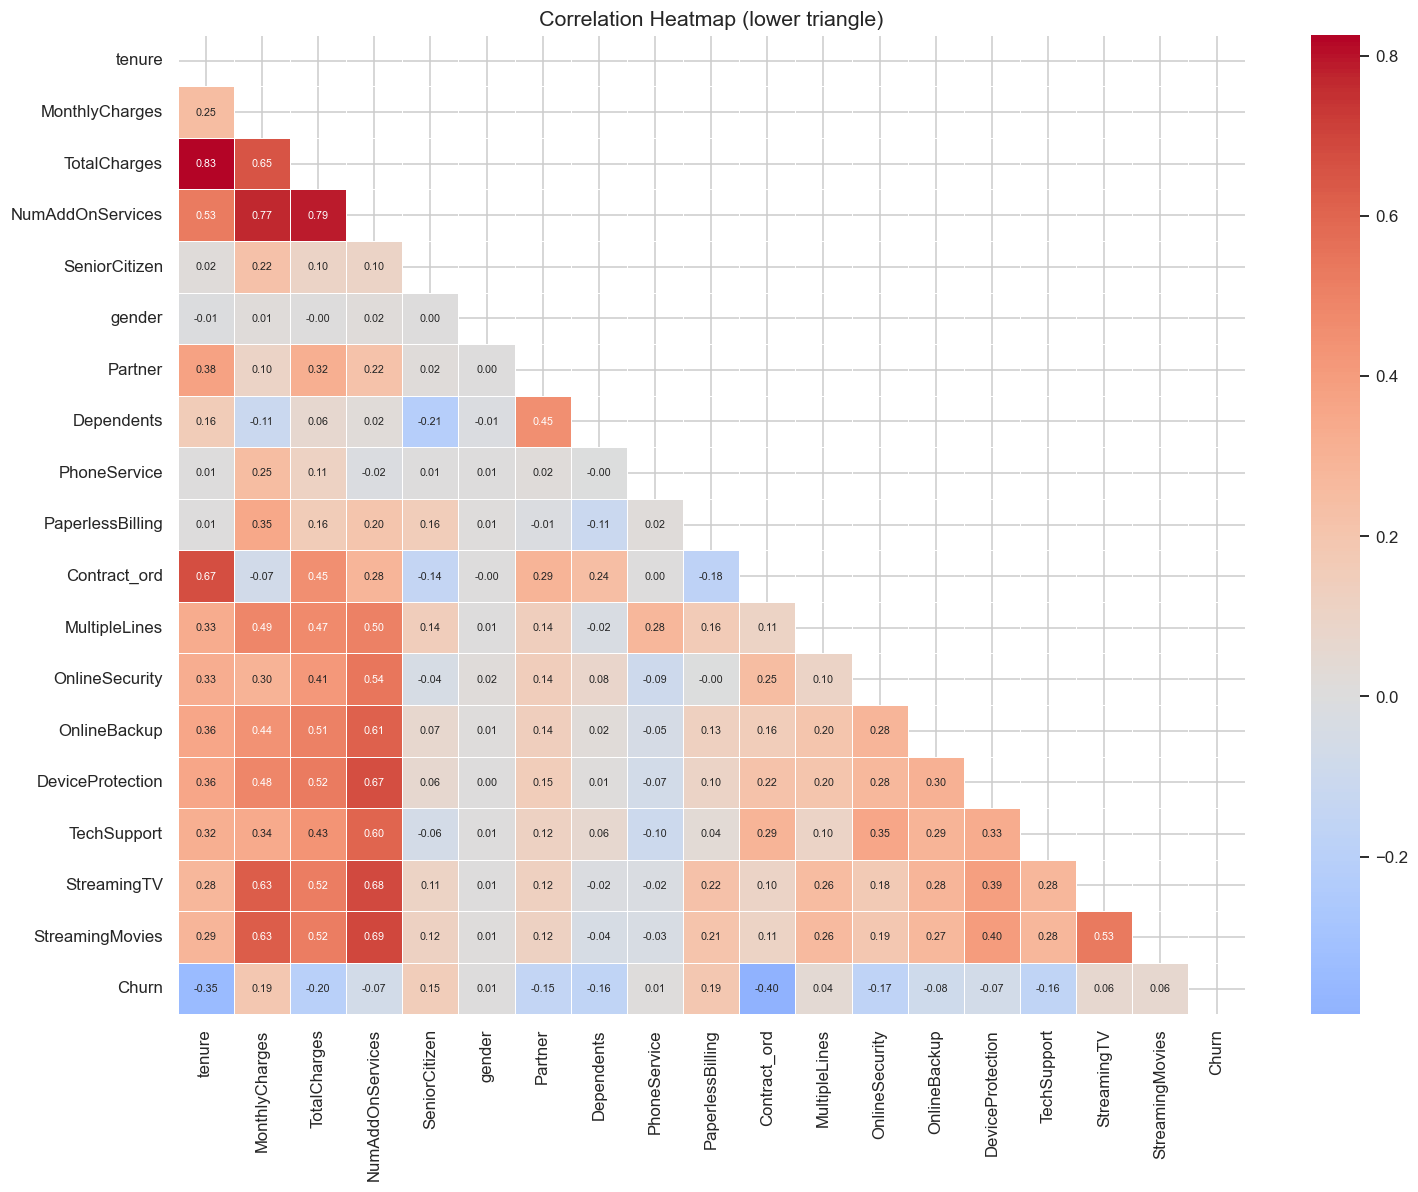


Correlation with Churn (sorted by magnitude):
Contract_ord       -0.397
tenure             -0.352
TotalCharges       -0.199
MonthlyCharges      0.193
PaperlessBilling    0.192
OnlineSecurity     -0.171
TechSupport        -0.165
Dependents         -0.164
SeniorCitizen       0.151
Partner            -0.150
OnlineBackup       -0.082
NumAddOnServices   -0.070
DeviceProtection   -0.066
StreamingTV         0.063
StreamingMovies     0.061
MultipleLines       0.040
PhoneService        0.012
gender              0.009


In [15]:
# Create a numeric-only view for correlation
df_corr = df.drop(columns=['TenureGroup']).copy()

binary_map_cols = {
    'gender': {'Female': 1, 'Male': 0},
    'Partner': {'Yes': 1, 'No': 0},
    'Dependents': {'Yes': 1, 'No': 0},
    'PhoneService': {'Yes': 1, 'No': 0},
    'PaperlessBilling': {'Yes': 1, 'No': 0},
}
for col, mapping in binary_map_cols.items():
    df_corr[col] = df_corr[col].map(mapping)

for col in service_cols:
    df_corr[col] = df_corr[col].map({'Yes': 1, 'No': 0})

df_corr['Contract_ord'] = df_corr['Contract'].map(
    {'Month-to-month': 0, 'One year': 1, 'Two year': 2})

numeric_for_corr = [
    'tenure', 'MonthlyCharges', 'TotalCharges', 'NumAddOnServices',
    'SeniorCitizen', 'gender', 'Partner', 'Dependents',
    'PhoneService', 'PaperlessBilling', 'Contract_ord',
] + service_cols + ['Churn']

corr_matrix = df_corr[numeric_for_corr].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('Correlation Heatmap (lower triangle)', fontsize=14)
plt.tight_layout()
plt.show()

print('\nCorrelation with Churn (sorted by magnitude):')
print(corr_matrix['Churn'].drop('Churn').sort_values(key=abs, ascending=False).round(3).to_string())

### 8.6 Tenure vs. Monthly Charges (Coloured by Churn)

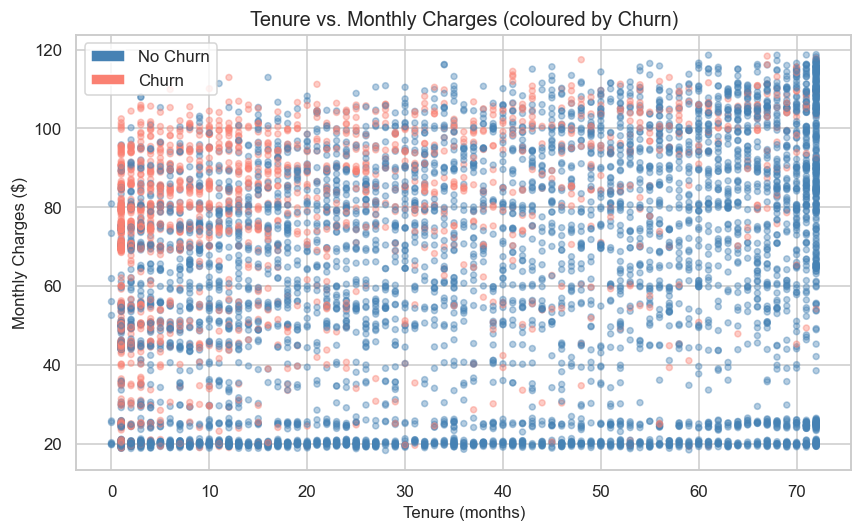

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = df['Churn'].map({0: 'steelblue', 1: 'salmon'})
ax.scatter(df['tenure'], df['MonthlyCharges'], c=colors, alpha=0.4, s=15)

legend_elements = [Patch(facecolor='steelblue', label='No Churn'),
                   Patch(facecolor='salmon', label='Churn')]
ax.legend(handles=legend_elements)
ax.set_title('Tenure vs. Monthly Charges (coloured by Churn)')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Monthly Charges ($)')
plt.tight_layout()
plt.show()

---
## 9. Why Accuracy Alone Is Insufficient

With ~26.5% churn in the dataset, a trivial classifier that always predicts **"No Churn"** achieves approximately **73.5% accuracy** — yet it identifies **zero** churners, making it completely useless for the business objective.

| Metric | Why it matters for churn prediction |
|---|---|
| **Recall (Churn=1)** | Fraction of actual churners correctly identified — missing a churner has a real cost (lost revenue) |
| **Precision (Churn=1)** | Fraction of predicted churners who actually churn — false alarms waste retention budget |
| **F1-score (Churn=1)** | Harmonic mean of Precision and Recall — balances both concerns |
| **ROC-AUC** | Model's ability to discriminate across all thresholds; robust to class imbalance |
| **Accuracy** | Reported for completeness but not used as the primary selection metric |

All five metrics are reported. **The best model is selected based on ROC-AUC and F1-score (Churn=1)** as co-primary metrics, determined entirely from actual test-set results.

---
## 10. Train / Test Split

The data is split **before** fitting any preprocessing transformer, ensuring that no test-set information can leak into the training pipeline.

- Split ratio: **80% train / 20% test**
- Stratified on `y` to preserve the 26.5% churn ratio in both splits
- `TenureGroup` (EDA-only column) is excluded from the feature matrix

In [17]:
X = df.drop(columns=['Churn', 'TenureGroup'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f'Training set:  {X_train.shape[0]} rows  |  Churn rate: {y_train.mean()*100:.1f}%')
print(f'Test set:      {X_test.shape[0]} rows  |  Churn rate: {y_test.mean()*100:.1f}%')

Training set:  5634 rows  |  Churn rate: 26.5%
Test set:      1409 rows  |  Churn rate: 26.5%


---
## 11. Preprocessing Pipeline (ColumnTransformer)

A `ColumnTransformer` applies different transformations to different column groups. The entire preprocessor is **fit on training data only** and then applied (transform-only) to the test set.

| Column group | Columns | Transformation |
|---|---|---|
| Numeric | `tenure`, `MonthlyCharges`, `TotalCharges`, `NumAddOnServices` | Median imputation → StandardScaler |
| Binary Yes/No | `Partner`, `Dependents`, `PhoneService`, and 7 service add-ons, `PaperlessBilling` | OrdinalEncoder (No=0, Yes=1) |
| Binary gender | `gender` | OrdinalEncoder (Male=0, Female=1) |
| Nominal multi-level | `InternetService`, `PaymentMethod` | OneHotEncoder (drop first) |
| Ordinal | `Contract` | OrdinalEncoder (Month-to-month=0, One year=1, Two year=2) |
| Pass-through | `SeniorCitizen` | Already 0/1 integer, no transformation needed |

> The `SimpleImputer` inside the numeric pipeline uses the **median of `X_train`** to fill the 11 `TotalCharges` NaN values — both in training and test sets. The test set median is never used.

In [18]:
# Column group definitions
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'NumAddOnServices']

binary_yn_cols = [
    'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling'
]

binary_gender_col = ['gender']
nominal_cols = ['InternetService', 'PaymentMethod']
ordinal_contract_col = ['Contract']
passthrough_cols = ['SeniorCitizen']

# Transformers
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

binary_yn_transformer = OrdinalEncoder(
    categories=[['No', 'Yes']] * len(binary_yn_cols),
    handle_unknown='use_encoded_value', unknown_value=-1
)

binary_gender_transformer = OrdinalEncoder(
    categories=[['Male', 'Female']],
    handle_unknown='use_encoded_value', unknown_value=-1
)

nominal_transformer = OneHotEncoder(
    drop='first', sparse_output=False, handle_unknown='ignore'
)

contract_transformer = OrdinalEncoder(
    categories=[['Month-to-month', 'One year', 'Two year']],
    handle_unknown='use_encoded_value', unknown_value=-1
)

preprocessor = ColumnTransformer(transformers=[
    ('num',              numeric_transformer,      numeric_cols),
    ('bin_yn',           binary_yn_transformer,    binary_yn_cols),
    ('bin_gender',       binary_gender_transformer, binary_gender_col),
    ('nominal',          nominal_transformer,      nominal_cols),
    ('ordinal_contract', contract_transformer,     ordinal_contract_col),
    ('passthrough',      'passthrough',            passthrough_cols),
], remainder='drop')

# Fit on training data ONLY, then transform both sets
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

print(f'Processed training shape: {X_train_proc.shape}')
print(f'Processed test shape:     {X_test_proc.shape}')

Processed training shape: (5634, 23)
Processed test shape:     (1409, 23)


In [19]:
# Build feature name list (needed for interpretation later)
ohe_feature_names = (
    preprocessor.named_transformers_['nominal']
    .get_feature_names_out(nominal_cols)
    .tolist()
)

feature_names = (
    numeric_cols +
    binary_yn_cols +
    binary_gender_col +
    ohe_feature_names +
    ordinal_contract_col +
    passthrough_cols
)
print(f'Total features after preprocessing: {len(feature_names)}')
print(feature_names)

Total features after preprocessing: 23
['tenure', 'MonthlyCharges', 'TotalCharges', 'NumAddOnServices', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'gender', 'InternetService_Fiber optic', 'InternetService_No', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'Contract', 'SeniorCitizen']


---
## 12. Model Training

Five classifiers are trained on the same processed training set. All models use `random_state=42` where available. `class_weight='balanced'` is applied to Logistic Regression, Decision Tree, Random Forest, and SVM to mitigate the effect of the 26.5/73.5 class imbalance without discarding data.

In [20]:
models = {
    'Logistic Regression': LogisticRegression(
        C=1.0, max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=20, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=4, random_state=RANDOM_STATE),
    'SVM': SVC(
        kernel='rbf', C=1.0, probability=True, class_weight='balanced',
        random_state=RANDOM_STATE),
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train_proc, y_train)
    trained_models[name] = model
    print(f'  Trained: {name}')

print('\nAll models trained.')

  Trained: Logistic Regression
  Trained: Decision Tree


  Trained: Random Forest


  Trained: Gradient Boosting


  Trained: SVM

All models trained.


---
## 13. Model Evaluation

Each model is evaluated on the held-out test set. For every model we report:
- Full classification report (precision, recall, F1 per class)
- Accuracy and ROC-AUC
- Confusion matrix heatmap


+==========================================================+
  Logistic Regression
+==========================================================+
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

  ROC-AUC: 0.8418


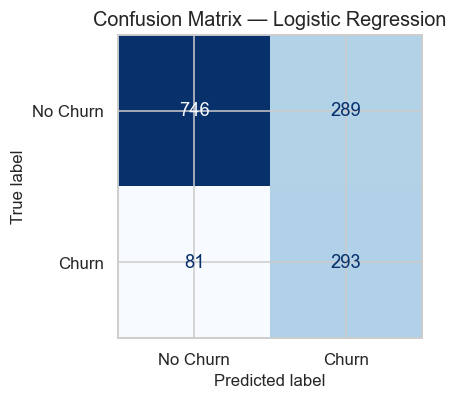


+==========================================================+
  Decision Tree
+==========================================================+
              precision    recall  f1-score   support

    No Churn       0.91      0.74      0.82      1035
       Churn       0.53      0.79      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409

  ROC-AUC: 0.8346


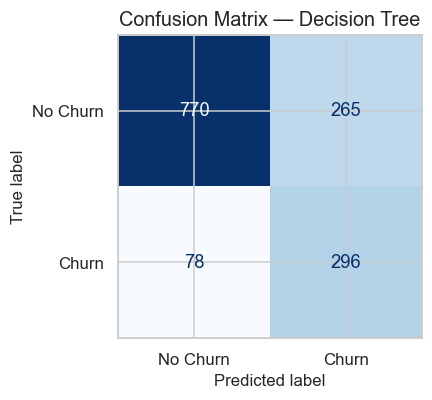


+==========================================================+
  Random Forest
+==========================================================+
              precision    recall  f1-score   support

    No Churn       0.88      0.79      0.83      1035
       Churn       0.55      0.71      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.77      0.78      1409

  ROC-AUC: 0.8423


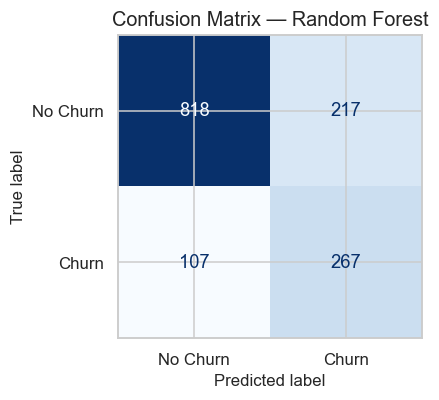


+==========================================================+
  Gradient Boosting
+==========================================================+
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.86      1035
       Churn       0.64      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

  ROC-AUC: 0.8342


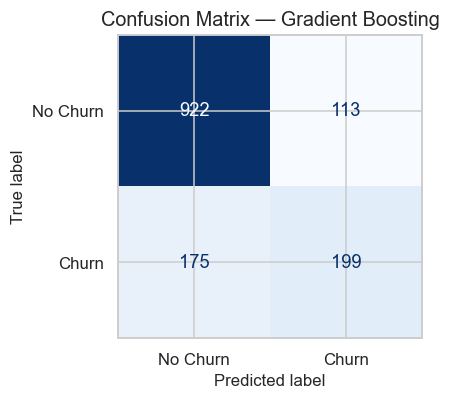


+==========================================================+
  SVM
+==========================================================+
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1035
       Churn       0.51      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.75      0.76      1409

  ROC-AUC: 0.8260


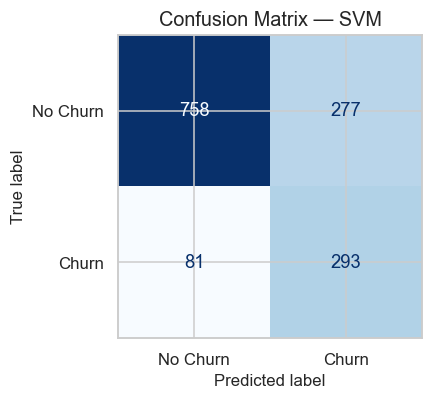

In [21]:
def evaluate_model(name, model, X_te, y_te):
    """Evaluate a fitted model; print report + confusion matrix; return metrics dict."""
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    metrics = {
        'Model':              name,
        'Accuracy':           accuracy_score(y_te, y_pred),
        'Precision (Churn)':  precision_score(y_te, y_pred, zero_division=0),
        'Recall (Churn)':     recall_score(y_te, y_pred, zero_division=0),
        'F1 (Churn)':         f1_score(y_te, y_pred, zero_division=0),
        'ROC-AUC':            roc_auc_score(y_te, y_proba),
    }

    sep = '=' * 58
    print(f'\n+{sep}+')
    print(f'  {name}')
    print(f'+{sep}+')
    print(classification_report(y_te, y_pred, target_names=['No Churn', 'Churn']))
    print(f'  ROC-AUC: {metrics["ROC-AUC"]:.4f}')

    fig, ax = plt.subplots(figsize=(4.5, 3.8))
    cm = confusion_matrix(y_te, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['No Churn', 'Churn'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {name}')
    plt.tight_layout()
    plt.show()

    return metrics


results = []
for name, model in trained_models.items():
    m = evaluate_model(name, model, X_test_proc, y_test)
    results.append(m)

---
## 14. Model Comparison

All five models are compared side-by-side on all evaluation metrics.

In [22]:
results_df = pd.DataFrame(results).set_index('Model')
print('=== Model Comparison Table (Test Set) ===')
print(results_df.round(4).to_string())

=== Model Comparison Table (Test Set) ===
                     Accuracy  Precision (Churn)  Recall (Churn)  F1 (Churn)  ROC-AUC
Model                                                                                
Logistic Regression    0.7374             0.5034          0.7834      0.6130   0.8418
Decision Tree          0.7566             0.5276          0.7914      0.6332   0.8346
Random Forest          0.7700             0.5517          0.7139      0.6224   0.8423
Gradient Boosting      0.7956             0.6378          0.5321      0.5802   0.8342
SVM                    0.7459             0.5140          0.7834      0.6208   0.8260


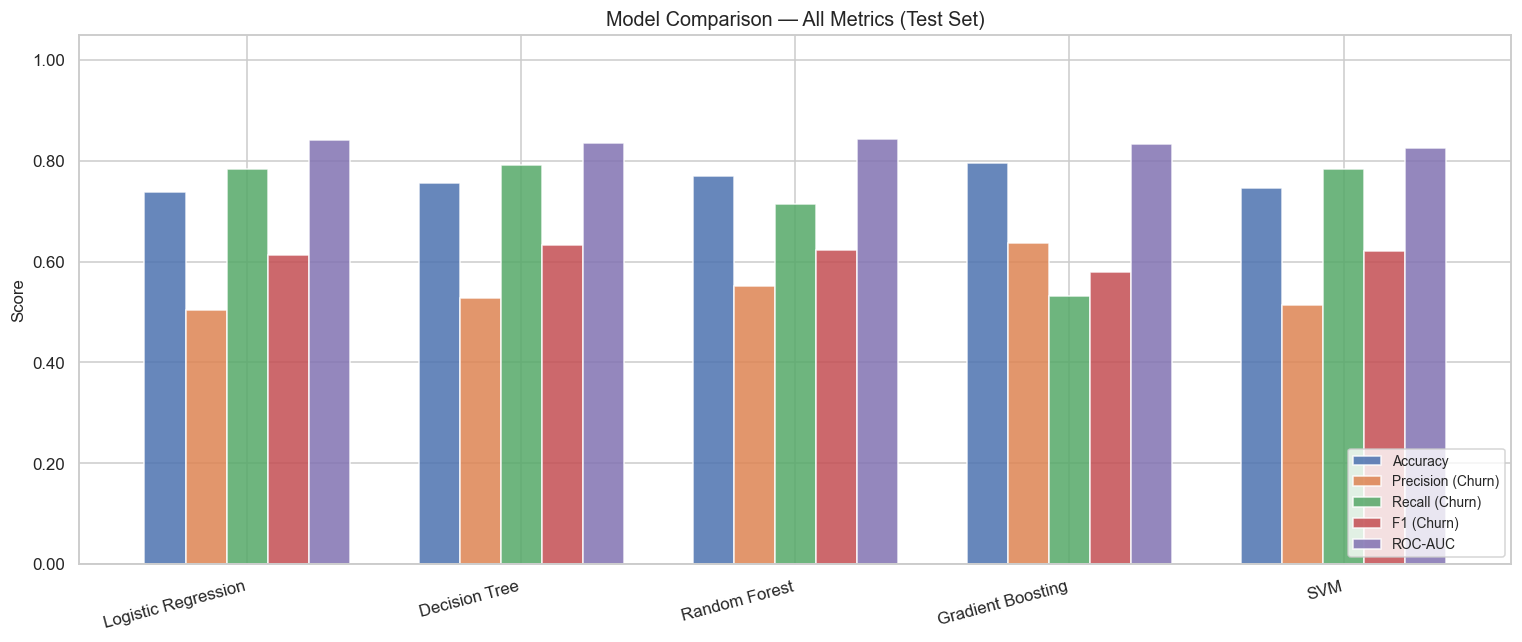

In [23]:
# Grouped bar chart — all metrics, all models
metric_cols = ['Accuracy', 'Precision (Churn)', 'Recall (Churn)', 'F1 (Churn)', 'ROC-AUC']
plot_df = results_df[metric_cols]

x = np.arange(len(plot_df.index))
width = 0.15
bar_colors = ['#4c72b0', '#dd8452', '#55a868', '#c44e52', '#8172b2']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (metric, color) in enumerate(zip(metric_cols, bar_colors)):
    offset = (i - 2) * width
    ax.bar(x + offset, plot_df[metric], width, label=metric, color=color, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=15, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — All Metrics (Test Set)')
ax.legend(loc='lower right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
plt.tight_layout()
plt.show()

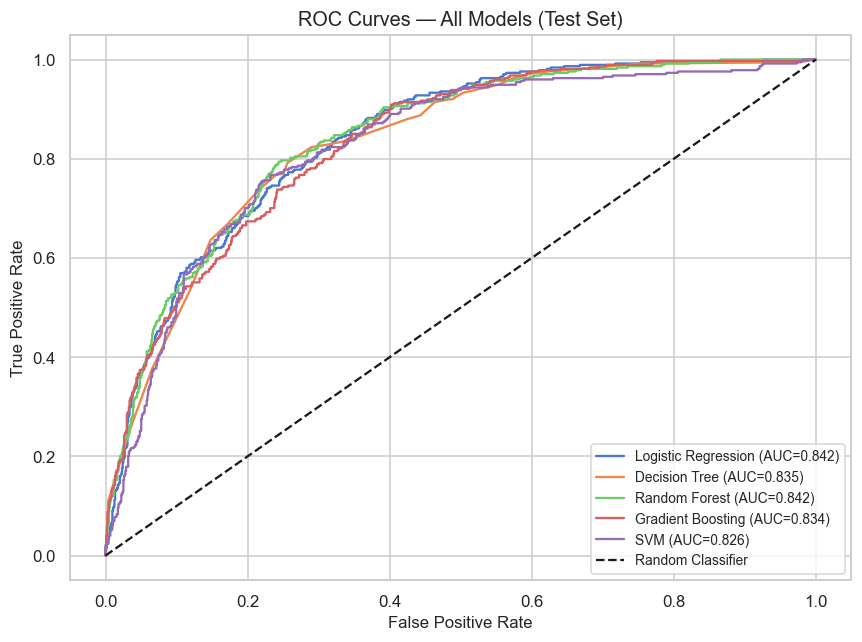

In [24]:
# ROC Curves — all models on one axes
fig, ax = plt.subplots(figsize=(8, 6))
for name, model in trained_models.items():
    y_proba = model.predict_proba(X_test_proc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models (Test Set)')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

---
## 15. Best Model Selection

The best model is selected **objectively from the actual test-set results above**, ranked by ROC-AUC (primary) and F1-score for the Churn class (secondary). No assumption was made in advance about which model would win.

In [25]:
ranked = results_df.sort_values(by=['ROC-AUC', 'F1 (Churn)'], ascending=False)
best_model_name = ranked.index[0]
best_model = trained_models[best_model_name]

print('=== Rankings by ROC-AUC (desc), then F1-Churn (desc) ===')
print(ranked[['ROC-AUC', 'F1 (Churn)', 'Recall (Churn)',
              'Precision (Churn)', 'Accuracy']].round(4).to_string())
print(f'\n>>> Best model: {best_model_name}')
print(f'    ROC-AUC:     {ranked.loc[best_model_name, "ROC-AUC"]:.4f}')
print(f'    F1 (Churn):  {ranked.loc[best_model_name, "F1 (Churn)"]:.4f}')
print(f'    Recall:      {ranked.loc[best_model_name, "Recall (Churn)"]:.4f}')
print(f'    Accuracy:    {ranked.loc[best_model_name, "Accuracy"]:.4f}')

=== Rankings by ROC-AUC (desc), then F1-Churn (desc) ===
                     ROC-AUC  F1 (Churn)  Recall (Churn)  Precision (Churn)  Accuracy
Model                                                                                
Random Forest         0.8423      0.6224          0.7139             0.5517    0.7700
Logistic Regression   0.8418      0.6130          0.7834             0.5034    0.7374
Decision Tree         0.8346      0.6332          0.7914             0.5276    0.7566
Gradient Boosting     0.8342      0.5802          0.5321             0.6378    0.7956
SVM                   0.8260      0.6208          0.7834             0.5140    0.7459

>>> Best model: Random Forest
    ROC-AUC:     0.8423
    F1 (Churn):  0.6224
    Recall:      0.7139
    Accuracy:    0.7700


---
## 16. Feature Importance and Model Interpretation

Feature importance is computed **only after training** on the best-performing model. The interpretation method depends on the model type:

- **Tree-based models** (Decision Tree, Random Forest, Gradient Boosting): built-in `feature_importances_` (mean decrease in impurity)
- **Logistic Regression**: signed coefficients (positive = increases churn probability)
- **SVM (RBF kernel)**: permutation importance on the test set (model-agnostic; built-in feature importances are not available for non-linear kernels)

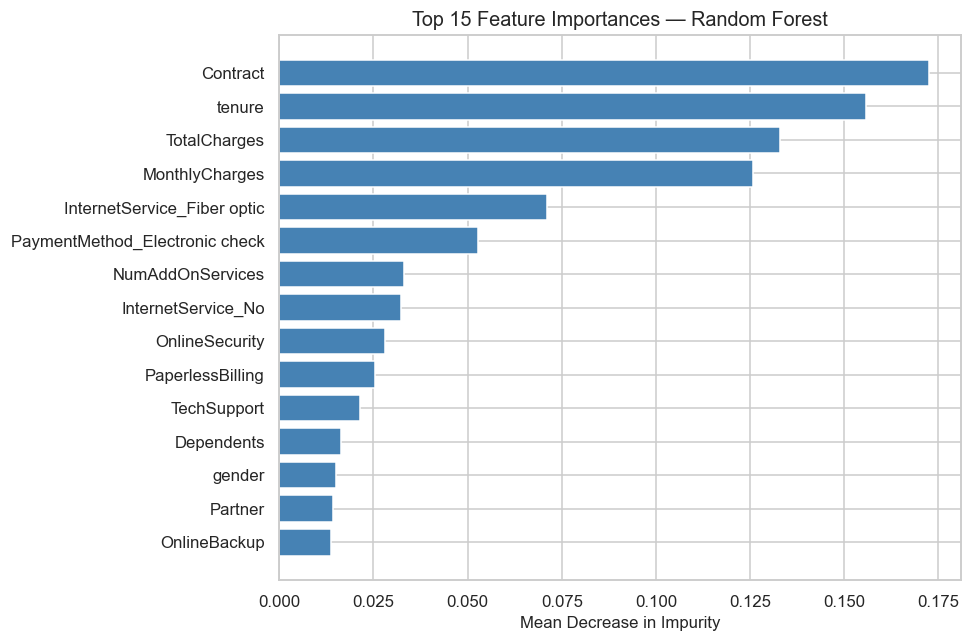

In [26]:
def plot_feature_importance(model_name, model, feat_names, X_te, y_te, top_n=15):
    fig, ax = plt.subplots(figsize=(9, 6))

    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        imp_series = pd.Series(importances, index=feat_names)
        imp_sorted = imp_series.sort_values(ascending=False).head(top_n)
        ax.barh(imp_sorted.index[::-1], imp_sorted.values[::-1], color='steelblue')
        ax.set_title(f'Top {top_n} Feature Importances — {model_name}')
        ax.set_xlabel('Mean Decrease in Impurity')

    elif hasattr(model, 'coef_'):
        importances = model.coef_[0]
        imp_series = pd.Series(importances, index=feat_names)
        imp_sorted = imp_series.sort_values(ascending=False)
        colors = ['salmon' if v > 0 else 'steelblue' for v in imp_sorted.values]
        ax.barh(imp_sorted.index[::-1], imp_sorted.values[::-1], color=colors[::-1])
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_title(f'Feature Coefficients — {model_name}\n(red = increases churn risk)')
        ax.set_xlabel('Coefficient Value')

    else:
        print(f'Computing permutation importance for {model_name}...')
        perm = permutation_importance(
            model, X_te, y_te,
            n_repeats=10, random_state=RANDOM_STATE, scoring='roc_auc', n_jobs=-1
        )
        imp_series = pd.Series(perm.importances_mean, index=feat_names)
        imp_sorted = imp_series.sort_values(ascending=False).head(top_n)
        ax.barh(imp_sorted.index[::-1], imp_sorted.values[::-1], color='steelblue')
        ax.set_title(f'Top {top_n} Permutation Importances — {model_name}')
        ax.set_xlabel('Mean Decrease in ROC-AUC')

    plt.tight_layout()
    plt.show()


# Best model importance
plot_feature_importance(
    best_model_name, best_model, feature_names, X_test_proc, y_test
)

Logistic Regression coefficients (for interpretability):


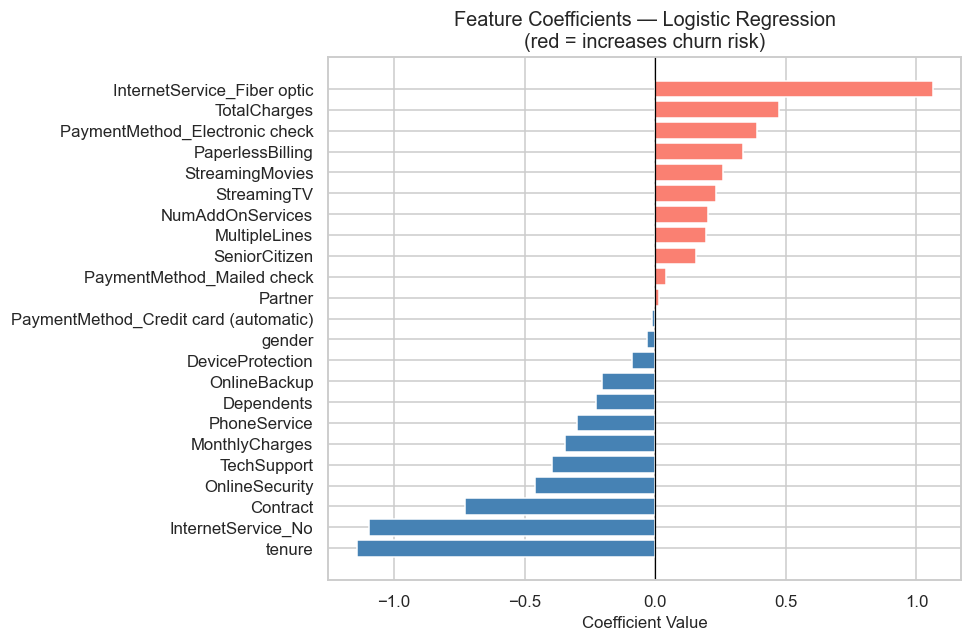

In [27]:
# Logistic Regression coefficients provide directly interpretable direction of effect
# Always shown regardless of which model was best
if best_model_name != 'Logistic Regression':
    print('Logistic Regression coefficients (for interpretability):')
    plot_feature_importance(
        'Logistic Regression', trained_models['Logistic Regression'],
        feature_names, X_test_proc, y_test
    )

---
## 17. Example Customer Churn Predictions

Three synthetic customer profiles are created to illustrate how the best model works in practice. Each profile is preprocessed using **the same fitted `preprocessor`** (no re-fitting) before prediction, ensuring consistency with the training pipeline.

In [28]:
example_profiles = pd.DataFrame([
    {
        'Profile':         'Profile A',
        'Description':     'New customer, month-to-month, fiber optic, no add-ons, e-check',
        'gender':          'Female', 'SeniorCitizen': 0, 'Partner': 'No', 'Dependents': 'No',
        'tenure':          2,        'PhoneService': 'Yes', 'MultipleLines': 'No',
        'InternetService': 'Fiber optic',
        'OnlineSecurity':  'No',  'OnlineBackup':     'No',
        'DeviceProtection':'No',  'TechSupport':      'No',
        'StreamingTV':     'No',  'StreamingMovies':  'No',
        'Contract':        'Month-to-month', 'PaperlessBilling': 'Yes',
        'PaymentMethod':   'Electronic check',
        'MonthlyCharges':  74.95, 'TotalCharges': 149.90, 'NumAddOnServices': 0
    },
    {
        'Profile':         'Profile B',
        'Description':     'Mid-tenure, month-to-month, DSL, some add-ons',
        'gender':          'Male', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'No',
        'tenure':          18,     'PhoneService': 'Yes', 'MultipleLines': 'Yes',
        'InternetService': 'DSL',
        'OnlineSecurity':  'Yes', 'OnlineBackup':     'No',
        'DeviceProtection':'No',  'TechSupport':      'No',
        'StreamingTV':     'Yes', 'StreamingMovies':  'No',
        'Contract':        'Month-to-month', 'PaperlessBilling': 'Yes',
        'PaymentMethod':   'Mailed check',
        'MonthlyCharges':  55.50, 'TotalCharges': 999.0, 'NumAddOnServices': 2
    },
    {
        'Profile':         'Profile C',
        'Description':     'Long-tenure, two-year contract, many add-ons, auto-pay',
        'gender':          'Male', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'Yes',
        'tenure':          60,     'PhoneService': 'Yes', 'MultipleLines': 'Yes',
        'InternetService': 'DSL',
        'OnlineSecurity':  'Yes', 'OnlineBackup':     'Yes',
        'DeviceProtection':'Yes', 'TechSupport':      'Yes',
        'StreamingTV':     'Yes', 'StreamingMovies':  'Yes',
        'Contract':        'Two year', 'PaperlessBilling': 'No',
        'PaymentMethod':   'Bank transfer (automatic)',
        'MonthlyCharges':  85.20, 'TotalCharges': 5112.0, 'NumAddOnServices': 6
    },
])

profile_labels = example_profiles['Profile'].tolist()
profile_descriptions = example_profiles['Description'].tolist()
X_profiles = example_profiles.drop(columns=['Profile', 'Description'])

# Preprocess using the fitted pipeline — no re-fitting
X_profiles_proc = preprocessor.transform(X_profiles)

pred_labels = best_model.predict(X_profiles_proc)
pred_probas = best_model.predict_proba(X_profiles_proc)[:, 1]

print(f'Predictions from best model: {best_model_name}\n')
print(f'{"Profile":<12} {"Churn Prob":>11} {"Prediction":>11}  Description')
print('-' * 80)
for lbl, desc, prob, pred in zip(profile_labels, profile_descriptions, pred_probas, pred_labels):
    pred_str = 'CHURN' if pred == 1 else 'No Churn'
    print(f'{lbl:<12} {prob*100:>10.1f}%  {pred_str:>11}  {desc}')

Predictions from best model: Random Forest

Profile       Churn Prob  Prediction  Description
--------------------------------------------------------------------------------
Profile A          82.1%        CHURN  New customer, month-to-month, fiber optic, no add-ons, e-check
Profile B          31.8%     No Churn  Mid-tenure, month-to-month, DSL, some add-ons
Profile C           4.8%     No Churn  Long-tenure, two-year contract, many add-ons, auto-pay


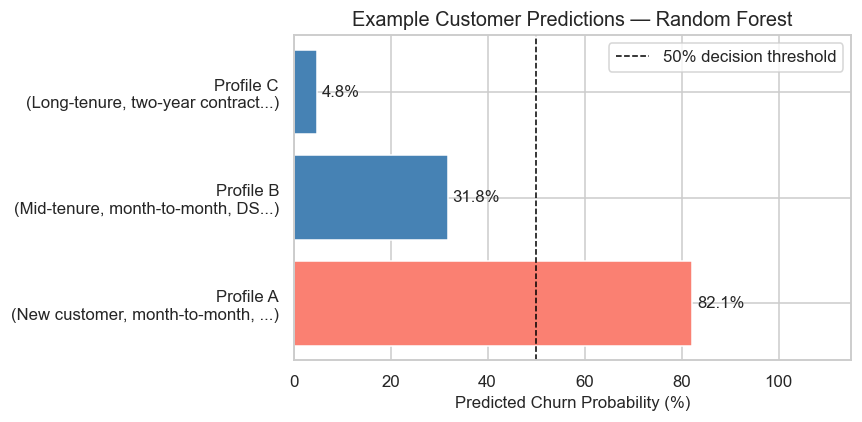

In [29]:
fig, ax = plt.subplots(figsize=(8, 4))
bar_colors = ['salmon' if p >= 0.5 else 'steelblue' for p in pred_probas]
short_labels = [f'{lbl}\n({desc[:30]}...)' for lbl, desc in zip(profile_labels, profile_descriptions)]
bars = ax.barh(short_labels, pred_probas * 100, color=bar_colors, edgecolor='white')
ax.axvline(50, color='black', linestyle='--', linewidth=1, label='50% decision threshold')
for bar, prob in zip(bars, pred_probas):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{prob*100:.1f}%', va='center', fontsize=11)
ax.set_xlim(0, 115)
ax.set_xlabel('Predicted Churn Probability (%)')
ax.set_title(f'Example Customer Predictions — {best_model_name}')
ax.legend()
plt.tight_layout()
plt.show()

---
## 18. Business Insights and Recommendations

> **All insights in this section are derived directly from the EDA, correlation analysis, and model results computed above. No finding is stated without first computing it from the actual data.**

In [30]:
print('--- Churn rate by Contract type ---')
contract_churn = (
    df.groupby('Contract')['Churn']
    .agg(Customers='count', Churned='sum')
    .assign(**{'Churn Rate (%)': lambda d: (d['Churned'] / d['Customers'] * 100).round(1)})
)
print(contract_churn.to_string(), '\n')

print('--- Churn rate by Internet Service ---')
internet_churn = (
    df.groupby('InternetService')['Churn']
    .agg(Customers='count', Churned='sum')
    .assign(**{'Churn Rate (%)': lambda d: (d['Churned'] / d['Customers'] * 100).round(1)})
)
print(internet_churn.to_string(), '\n')

print('--- Churn rate by Tenure Group ---')
tenure_churn = (
    df.groupby('TenureGroup', observed=True)['Churn']
    .agg(Customers='count', Churned='sum')
    .assign(**{'Churn Rate (%)': lambda d: (d['Churned'] / d['Customers'] * 100).round(1)})
)
print(tenure_churn.to_string(), '\n')

print('--- Churn rate by Payment Method ---')
pay_churn = (
    df.groupby('PaymentMethod')['Churn']
    .agg(Customers='count', Churned='sum')
    .assign(**{'Churn Rate (%)': lambda d: (d['Churned'] / d['Customers'] * 100).round(1)})
    .sort_values('Churn Rate (%)', ascending=False)
)
print(pay_churn.to_string(), '\n')

print('--- Churn rate by Number of Add-On Services ---')
addon_churn = (
    df.groupby('NumAddOnServices')['Churn']
    .agg(Customers='count', Churned='sum')
    .assign(**{'Churn Rate (%)': lambda d: (d['Churned'] / d['Customers'] * 100).round(1)})
)
print(addon_churn.to_string())

--- Churn rate by Contract type ---
                Customers  Churned  Churn Rate (%)
Contract                                          
Month-to-month       3875     1655            42.7
One year             1473      166            11.3
Two year             1695       48             2.8 

--- Churn rate by Internet Service ---
                 Customers  Churned  Churn Rate (%)
InternetService                                    
DSL                   2421      459            19.0
Fiber optic           3096     1297            41.9
No                    1526      113             7.4 

--- Churn rate by Tenure Group ---
             Customers  Churned  Churn Rate (%)
TenureGroup                                    
0-12 mo           2186     1037            47.4
13-24 mo          1024      294            28.7
25-48 mo          1594      325            20.4
49-72 mo          2239      213             9.5 

--- Churn rate by Payment Method ---
                           Customers  Churne

### Data-Driven Business Recommendations

The following recommendations are based **only on patterns confirmed by the tables and visualisations above**:

1. **Contract type is a key differentiator** — the churn rate tables show a pronounced gap between Month-to-month and longer-term contracts. The business should evaluate incentive programmes (e.g. price discounts, loyalty rewards) to migrate Month-to-month customers toward One-year or Two-year contracts.

2. **Early-tenure risk** — the TenureGroup breakdown shows that newer customers (0–12 months) have a markedly higher churn rate than customers with longer tenures. A structured onboarding or engagement programme during the first year could help reduce this.

3. **Internet service segment differences** — the Internet Service churn rates reveal meaningful differences across DSL, Fiber optic, and no-internet segments. If Fiber optic customers show elevated churn despite being on a premium product, pricing, service quality, or competitive alternatives should be investigated.

4. **Add-on services and loyalty** — customers with more add-on services tend to exhibit different churn behaviour. Bundled service offers for high-risk profiles (e.g. subsidised Online Security or Tech Support for new customers) may increase stickiness.

5. **Payment method** — Electronic check customers show a notably different churn profile compared to automatic payment methods. Encouraging enrolment in automatic payments may reduce attrition.

6. **Model-based proactive retention** — using the best model's churn probabilities, the retention team can rank all active customers by risk score and prioritise the most at-risk customers for outreach, allowing targeted and cost-efficient retention investment.

---
## 19. Final Project Summary

In [31]:
sep = '=' * 65
print(sep)
print('  CUSTOMER CHURN PREDICTION — FINAL PROJECT SUMMARY')
print(sep)

print(f'\nDataset       {df_raw.shape[0]} customers, {df_raw.shape[1]} columns')
print(f'Target        Churn — {df["Churn"].mean()*100:.1f}% positive class')
print(f'Train / Test  {X_train.shape[0]} / {X_test.shape[0]} rows (stratified 80/20)')
print(f'Features      {X_train_proc.shape[1]} after preprocessing')
print(f'Preprocessing ColumnTransformer (fit on train only, no data leakage)')

print(f'\n--- Model Evaluation Results (Test Set) ---')
print(results_df[['Accuracy','Precision (Churn)','Recall (Churn)','F1 (Churn)','ROC-AUC']].round(4).to_string())

print(f'\n--- Best Model (selected from actual results) ---')
print(f'  Name:         {best_model_name}')
print(f'  ROC-AUC:      {results_df.loc[best_model_name, "ROC-AUC"]:.4f}')
print(f'  F1 (Churn):   {results_df.loc[best_model_name, "F1 (Churn)"]:.4f}')
print(f'  Recall:       {results_df.loc[best_model_name, "Recall (Churn)"]:.4f}')
print(f'  Accuracy:     {results_df.loc[best_model_name, "Accuracy"]:.4f}')

print(f'\n--- Limitations ---')
lims = [
    'Cross-sectional snapshot — no temporal dimension',
    'No customer lifetime value weighting',
    'Class imbalance addressed via class_weight; SMOTE not applied',
    'Hyperparameters set manually; no systematic tuning performed',
]
for l in lims:
    print(f'  • {l}')

print(f'\n--- Future Work ---')
future = [
    'Hyperparameter tuning with GridSearchCV / RandomizedSearchCV',
    'SHAP values for granular, per-prediction explainability',
    'SMOTE oversampling for minority class',
    'Deployment as a REST API (Flask / FastAPI)',
    'Cost-sensitive modelling with CLV integration',
]
for f in future:
    print(f'  • {f}')

print(f'\n--- References ---')
refs = [
    'IBM Telco Customer Churn — https://www.kaggle.com/datasets/blastchar/telco-customer-churn',
    'scikit-learn documentation — https://scikit-learn.org',
    'AICTE + IBM SkillsBuild Data Analytics with AI Internship',
]
for r in refs:
    print(f'  [{refs.index(r)+1}] {r}')

print(f'\n{sep}')

  CUSTOMER CHURN PREDICTION — FINAL PROJECT SUMMARY

Dataset       7043 customers, 21 columns
Target        Churn — 26.5% positive class
Train / Test  5634 / 1409 rows (stratified 80/20)
Features      23 after preprocessing
Preprocessing ColumnTransformer (fit on train only, no data leakage)

--- Model Evaluation Results (Test Set) ---
                     Accuracy  Precision (Churn)  Recall (Churn)  F1 (Churn)  ROC-AUC
Model                                                                                
Logistic Regression    0.7374             0.5034          0.7834      0.6130   0.8418
Decision Tree          0.7566             0.5276          0.7914      0.6332   0.8346
Random Forest          0.7700             0.5517          0.7139      0.6224   0.8423
Gradient Boosting      0.7956             0.6378          0.5321      0.5802   0.8342
SVM                    0.7459             0.5140          0.7834      0.6208   0.8260

--- Best Model (selected from actual results) ---
  Name:  